In [1]:
import pandas as pd

# Use python engine (more tolerant)
fake = pd.read_csv("Fake.csv", engine='python', encoding='latin1', on_bad_lines='skip')
real = pd.read_csv("True.csv", engine='python', encoding='latin1', on_bad_lines='skip')

# Add labels
fake["label"] = 1
real["label"] = 0

# Combine datasets
data = pd.concat([fake, real])

# Shuffle data
data = data.sample(frac=1).reset_index(drop=True)

# Keep only text and label
data = data[["text", "label"]]

# Show first rows
data.head()

,text,label
0,Lefty losers,1
1,President Obama typically refrains from outrig...,1
2,"During the annual White House Easter Egg Hunt,...",1
3,WASHINGTON (Reuters) - The U.S. Senate will mo...,0
4,ERBIL/BAGHDAD Iraq (Reuters) - Iraqi Kurdish l...,0


In [2]:
data["label"].value_counts()

,count
label,
1,23481
0,21417


In [3]:
# Remove missing values
data = data.dropna(subset=["text"])

# Convert everything to string (extra safety)
data["text"] = data["text"].astype(str)


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)

X = vectorizer.fit_transform(data["text"]).toarray()
y = data["label"]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))   # helps prevent overfitting

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 49s 41ms/step - accuracy: 0.9813 - loss: 0.0549 - val_accuracy: 0.9939 - val_loss: 0.0184
Epoch 2/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 87s 45ms/step - accuracy: 0.9982 - loss: 0.0056 - val_accuracy: 0.9949 - val_loss: 0.0170
Epoch 3/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 52s 46ms/step - accuracy: 0.9987 - loss: 0.0035 - val_accuracy: 0.9942 - val_loss: 0.0276
Epoch 4/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 50s 45ms/step - accuracy: 0.9994 - loss: 0.0023 - val_accuracy: 0.9933 - val_loss: 0.0297
Epoch 5/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 52s 47ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 0.9949 - val_loss: 0.0225
Epoch 6/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 44s 39ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9945 - val_loss: 0.0237
Epoch 7/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 82s 39ms/step - accuracy: 0.9997 - loss: 9.7321e-04 - val_accuracy: 0.9932 - val_loss: 0.0374
Epoch 8/15
1123/1123 ━━━━━━━━━━━━━━━━━━━━ 43s 38ms/step - accuracy: 0.99

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

281/281 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9943 - loss: 0.0466
Accuracy: 0.9943206906318665


In [11]:
def predict_news(text):
    vec = vectorizer.transform([text]).toarray()
    prediction = model.predict(vec)

    if prediction[0][0] > 0.5:
        print("Fake News ❌")
    else:
        print("Real News ✅")

# Try examples
predict_news("Scientists confirm water on Mars.")
predict_news("Aliens have taken over the government.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Real News ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Fake News ❌


In [12]:
model.save("fake_news_model.keras")

In [13]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model("fake_news_model.keras")

In [14]:
def predict_news(text):
    vec = vectorizer.transform([text]).toarray()
    prediction = loaded_model.predict(vec)

    if prediction[0][0] > 0.5:
        print("Fake News ❌")
    else:
        print("Real News ✅")

# Test
predict_news("Scientists confirm water on Mars.")
predict_news("Aliens have taken over the government.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Real News ✅
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Fake News ❌


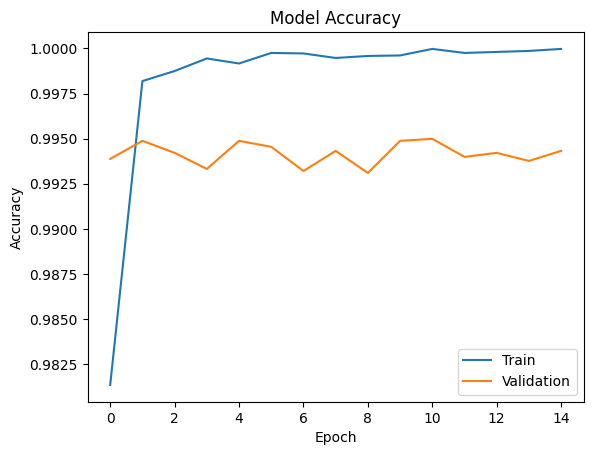

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

YARED GETACHEW
GROUP 1


1. What neural network architecture did you use?
I used a Feedforward Neural Network with an input layer, three hidden layers (256, 128, and 64 neurons), and one output layer.

2. How many epochs did you train your model?
The model was trained for 15 epochs.

3. What activation functions did you use?
I used the ReLU (Rectified Linear Unit) activation function for the hidden layers and the Sigmoid activation function for the output layer.

4. What accuracy did your model achieve?
The model achieved an accuracy of 0.9943206906318665=99.4% on the test dataset.

5. Bonus Improvement
I improved the model by increasing the number of neurons, adding dropout layers to prevent overfitting, and increasing the number of training epochs. This resulted in better performance compared to the initial model.